In [56]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import joblib
import mlflow

In [57]:
mlflow.set_experiment("CardProfiler")
mlflow.set_tracking_uri("http://127.0.0.1:8080")

In [58]:

df = pd.read_csv('../data/processed/df_clustered.csv')

features = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
            "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
X = df[features]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

target
Premium Clients         0.379
Low Activity Clients    0.349
Cash Users              0.271
Name: proportion, dtype: float64
target
Premium Clients         0.379
Low Activity Clients    0.350
Cash Users              0.271
Name: proportion, dtype: float64


In [59]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

pipelines = {}
rows = []

for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("classifier", model)])
    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = pipe.predict(X_test)
    pipelines[name] = pipe
    rows.append({
        "classifier": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall": recall_score(y_test, y_pred, average="macro"),
        "f1": f1_score(y_test, y_pred, average="macro"),
        "train_time_in_s": train_time,
    })

results = pd.DataFrame(rows).sort_values("f1", ascending=False).round(3)
results

,classifier,accuracy,precision,recall,f1,train_time_in_s
0,Random Forest,0.970,0.971,0.971,0.971,1.695
2,Decision Tree,0.937,0.939,0.940,0.939,0.093
1,SVM,0.920,0.919,0.923,0.921,0.991
3,Logistic Regression,0.906,0.908,0.908,0.908,0.430


In [60]:
def heat_map(estimator ,file ,  name=''):
    plt.figure(figsize=(6, 4))
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=estimator.classes_, yticklabels=estimator.classes_ )

    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(file, bbox_inches="tight")
    plt.show()
    plt.close()

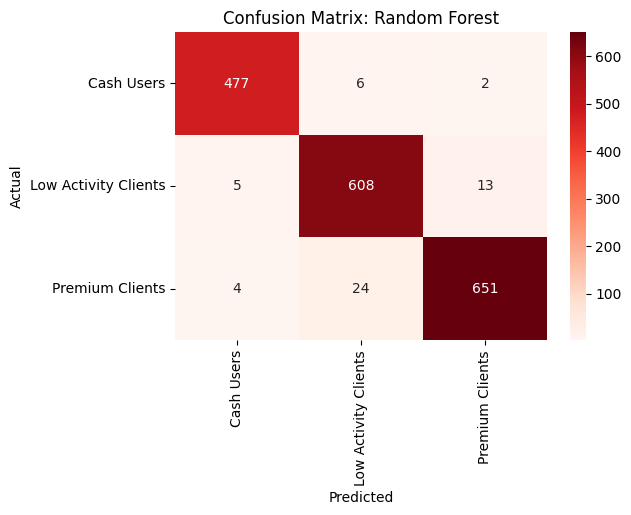

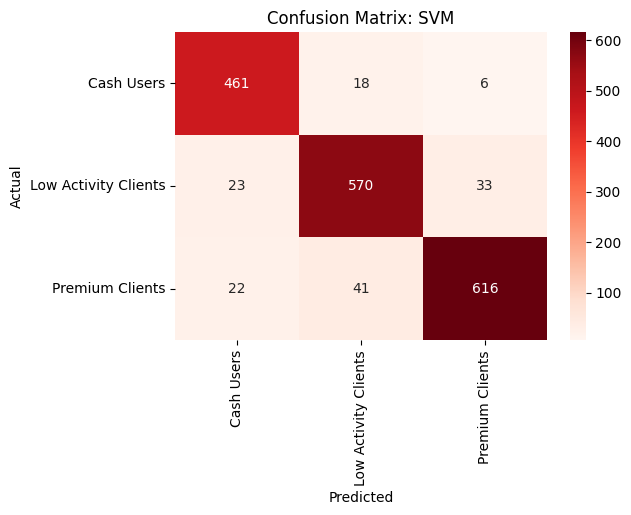

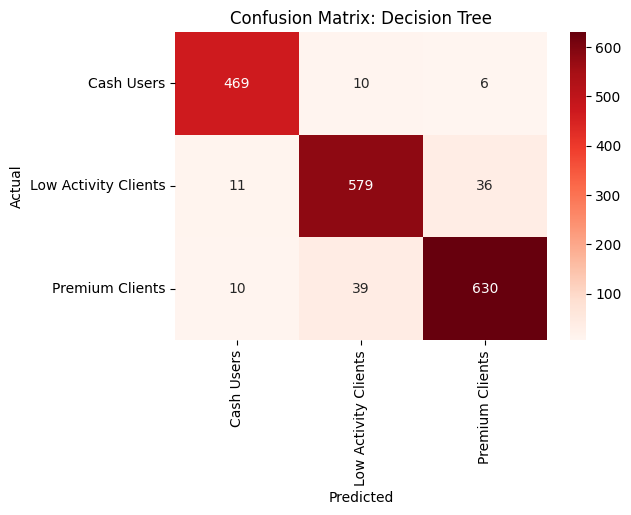

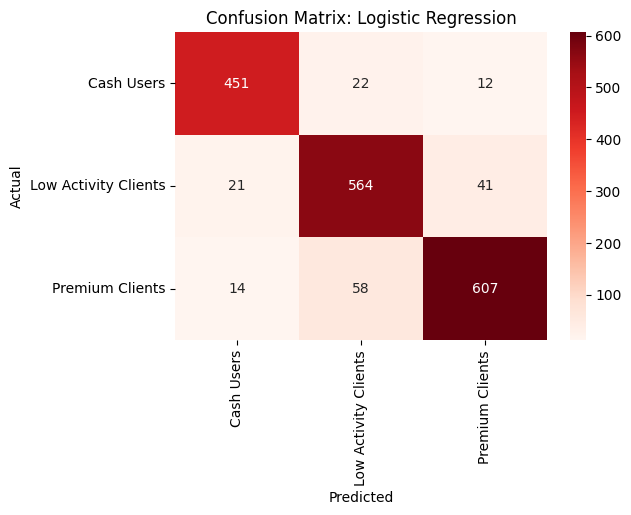

In [61]:


for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_)
    
    file = f"../confusion_matrices/default_{name.replace(' ', '_').lower()}.png"

    # heatmap function

    heat_map(pipe ,file , name)


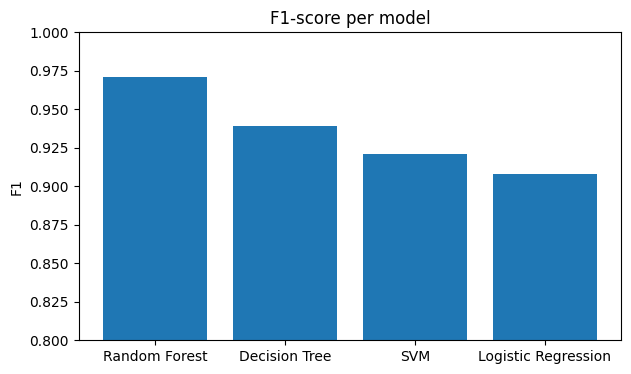

In [62]:
plt.figure(figsize=(7, 4))
plt.bar(results["classifier"], results["f1"])
plt.title("F1-score per model")
plt.ylabel("F1")
plt.ylim(0.8, 1.0)

plt.show()

In [63]:
def ml_flow(name, best_estimator, best_params, metrics, X_train, file):
    with mlflow.start_run() as run:
            mlflow.log_params(best_params)
            mlflow.log_metrics(metrics)
            mlflow.log_artifact(file)
            mlflow.sklearn.log_model(
                best_estimator,
                name=name,
                input_example=X_train[:2],
                skops_trusted_types=["sklearn.tree._tree.Tree"],)

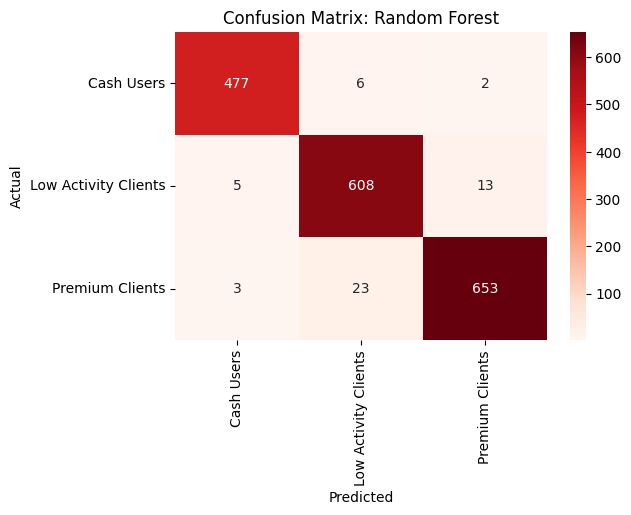

2026/10/08 22:08:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run kindly-horse-296 at: http://127.0.0.1:8080/#/experiments/2/runs/de7242385a0847cd9cf91e547054e6ad
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


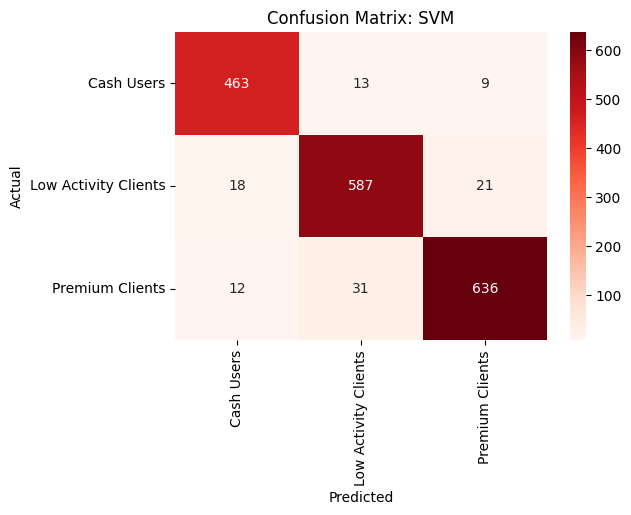

2026/10/08 22:09:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run wise-shrew-414 at: http://127.0.0.1:8080/#/experiments/2/runs/fa78755a3f9d442eb7f92193f79ed38a
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


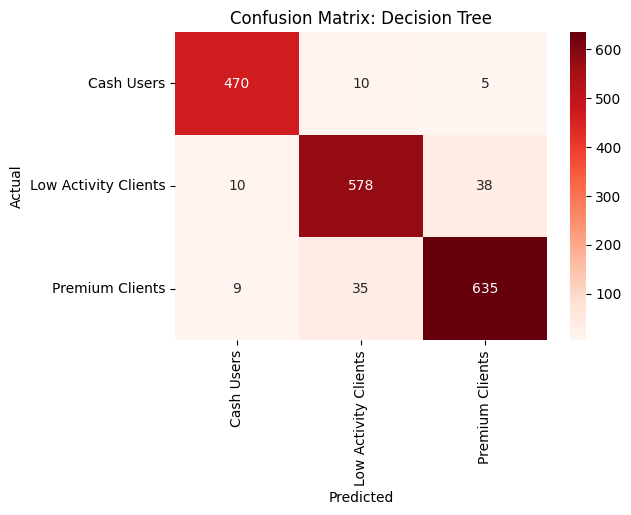

2026/10/08 22:09:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run upbeat-grub-728 at: http://127.0.0.1:8080/#/experiments/2/runs/c67cf631ab134e9e9d2714585f45da10
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


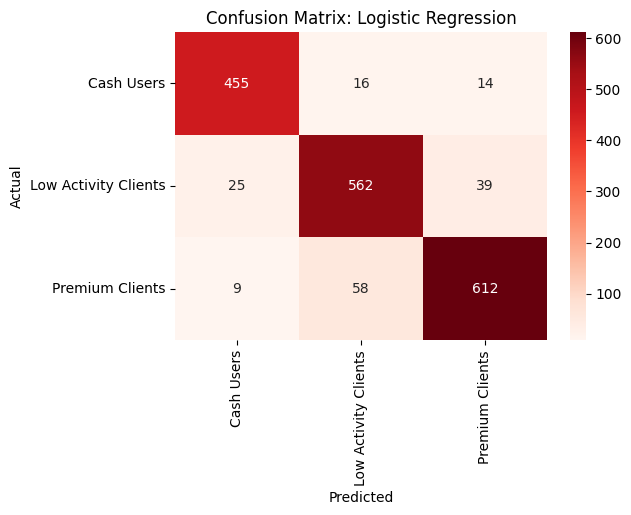

2026/10/08 22:09:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run tasteful-ant-602 at: http://127.0.0.1:8080/#/experiments/2/runs/c19e707c4291429d83fcde75540b9b9c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "Random Forest": {"classifier__n_estimators": [100, 200],
                      "classifier__max_depth": [None, 10, 20]},

    "SVM": {"classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"]},

    "Decision Tree": {"classifier__max_depth": [None, 5, 10, 20],
                      "classifier__min_samples_split": [2, 5, 10]},
                      
    "Logistic Regression": {"classifier__C": [0.1, 1, 10]},
}

grids = {}
rows =  []
for name, classifier in models.items():

    pipe = Pipeline([("scaler", StandardScaler()), ("classifier", classifier)])
    gs = GridSearchCV(pipe, param_grids[name], cv=cv, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)

    best_params = gs.best_params_
    best_estimator = gs.best_estimator_

    y_pred = best_estimator.predict(X_test)

    # metrics

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    cm = confusion_matrix(y_test, y_pred)

    metrics = {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}
    


    # save dir
     
    file = f"../confusion_matrices/{name.replace(' ', '_').lower()}.png"

    # heatmap function

    heat_map(best_estimator ,file , name)


    # mlflow function
    
    ml_flow(name, best_estimator, best_params, metrics, X_train, file)
    
    grids[name] = gs
    rows.append({
        "classifier": name,
        "best_params": best_params,
        "cv_f1": gs.best_score_,
        "accuracy": accuracy,
        "f1": f1,
    })


In [66]:
results_tuned = pd.DataFrame(rows).sort_values("cv_f1", ascending=False).round(3)
results_tuned

,classifier,best_params,cv_f1,accuracy,f1
0,Random Forest,"{'classifier__max_depth': None, 'classifier__n...",0.966,0.971,0.972
1,SVM,"{'classifier__C': 10, 'classifier__kernel': 'r...",0.939,0.942,0.942
2,Decision Tree,"{'classifier__max_depth': 10, 'classifier__min...",0.937,0.940,0.942
3,Logistic Regression,{'classifier__C': 10},0.910,0.910,0.912


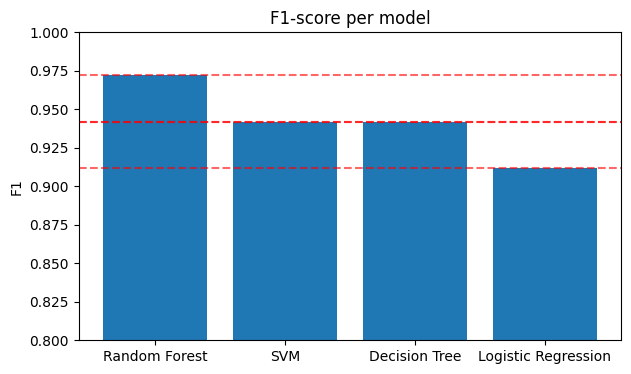

In [67]:
plt.figure(figsize=(7, 4))
plt.bar(results_tuned["classifier"], results_tuned["f1"])
plt.title("F1-score per model")
plt.ylabel("F1")
plt.ylim(0.8, 1.0)
for value in results_tuned["f1"]:
    plt.axhline(y=value, color="red", linestyle="--", alpha=0.6)

plt.show()

In [68]:
best_classifier_name = results_tuned.iloc[0]["classifier"]
best_pipeline = grids[best_classifier_name].best_estimator_
print(best_classifier_name, grids[best_classifier_name].best_params_)

Random Forest {'classifier__max_depth': None, 'classifier__n_estimators': 200}


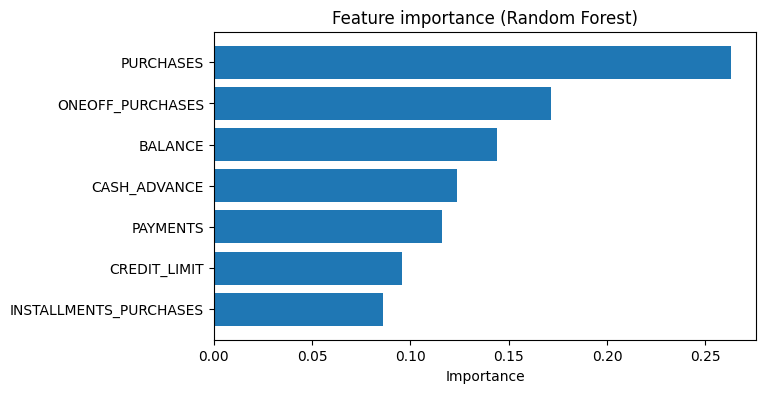

In [69]:
rf_pipeline = grids["Random Forest"].best_estimator_
importances = pd.Series(rf_pipeline.named_steps["classifier"].feature_importances_,
                        index=features).sort_values()

plt.figure(figsize=(7, 4))
plt.barh(importances.index, importances.values)
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.show()


In [70]:
rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Cash Users','Low Activity Clients','Premium Clients']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


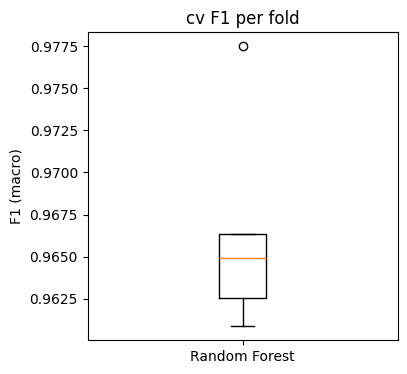

In [71]:
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring="f1_macro")

plt.figure(figsize=(4, 4))
plt.boxplot(cv_scores)
plt.xticks([1], [best_classifier_name])
plt.title("cv F1 per fold")
plt.ylabel("F1 (macro)")
plt.show()

In [72]:
joblib.dump(best_pipeline, '../models/final_pipeline.joblib')

['../models/final_pipeline.joblib']